## Train A Test A

### Classification

Category distribution:
0    11160
4     9693
3      830
2      604
1      227
6       71
5       63
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.92      0.91      0.92      2196
      Button       1.00      0.98      0.99        47
        Door       0.98      0.97      0.98       103
      Motion       0.95      0.81      0.87       171
      Socket       0.91      0.93      0.92      1980
 Temperature       0.94      0.88      0.91        17
   Vibration       1.00      0.94      0.97        16

    accuracy                           0.92      4530
   macro avg       0.96      0.92      0.94      4530
weighted avg       0.92      0.92      0.92      4530

Macro F1-Score: 0.9358


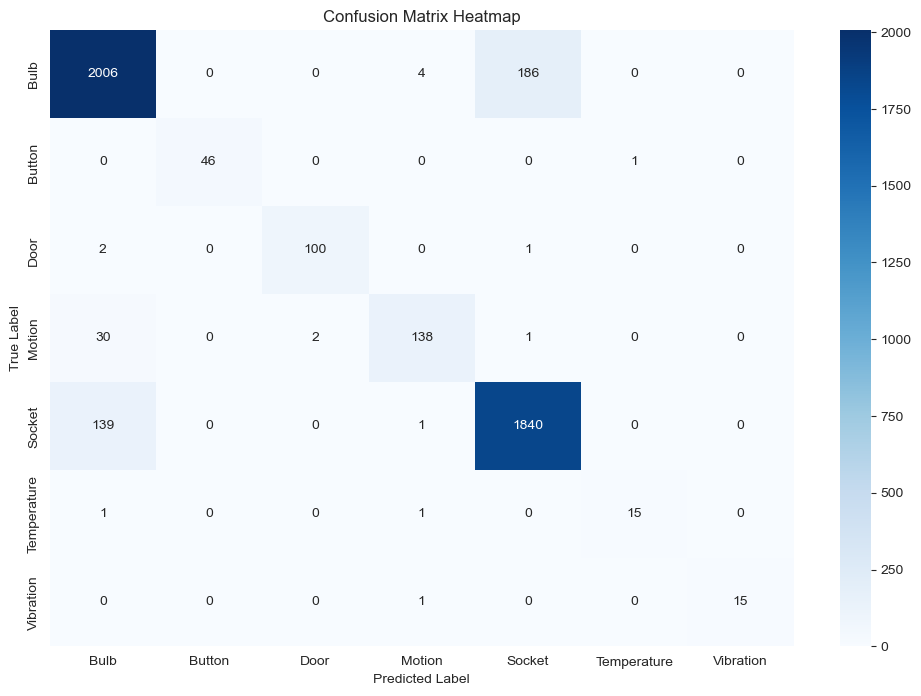

In [1]:
# Classification
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report,f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
file_path =  "./Merged_Data/B_6-Merged_sequence_data_fix_packets/Topology_A_fix_packets.csv"
data = pd.read_csv(file_path)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Type"]

y = y.astype('category')
categories = y.cat.categories  
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]
cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)
# Calculated Macro Average F1-Score
f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

### Identification

Category distribution:
5     3510
15    2700
12    2522
14    2500
13    2453
8     2201
9     1682
10    1245
6     1084
7      956
11     706
1      388
0      227
2      142
4       71
20      63
3       52
18      44
17      38
16      36
19      28
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       1.00      1.00      1.00        47
        Aqara Door 1       0.97      0.99      0.98        70
        Aqara Door 2       0.90      0.83      0.86        23
        Aqara Motion       1.00      1.00      1.00        13
     Aqara Vibration       1.00      0.88      0.93        16
       Ledvance Bulb       0.76      0.82      0.79       689
Ledvance Smart+ Plug       0.83      0.83      0.83       226
    Ledvance Z3 Plug       0.76      0.74      0.75       187
           Moes Bulb       0.88      0.95      0.92       421
      Philips Lamp 1       0.66      0.48      0.56       349
      Philips Lamp 2       0.77      

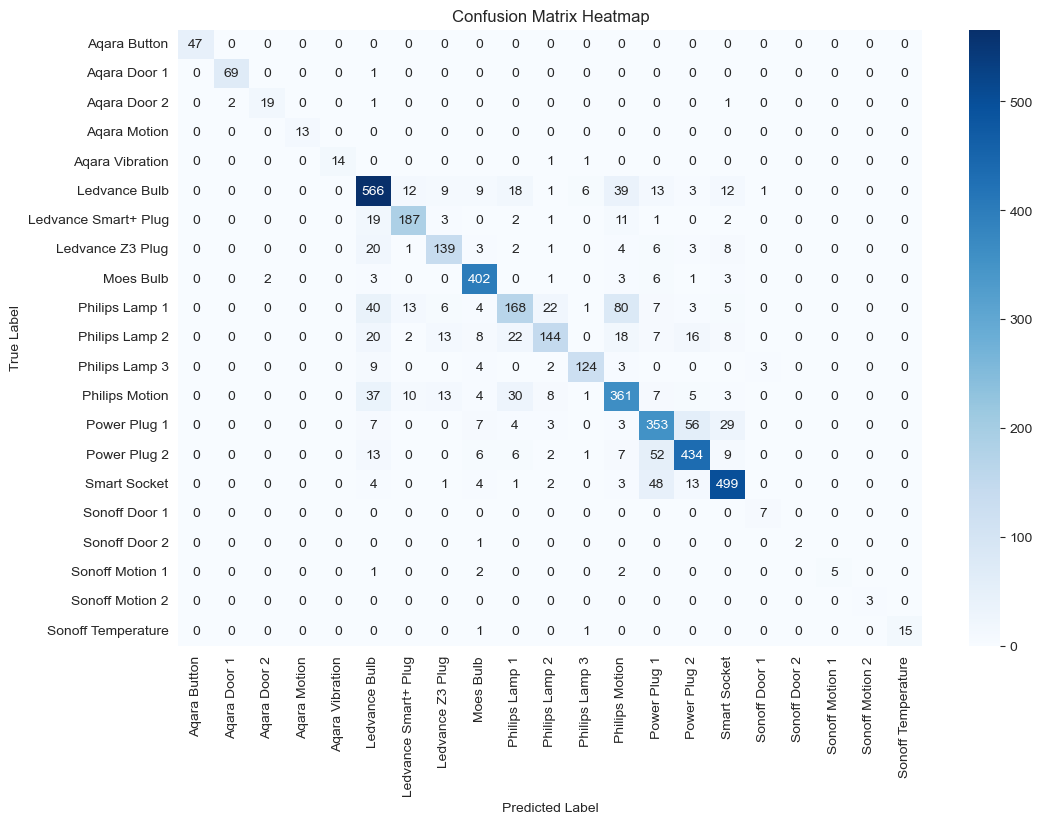

In [2]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

file_path =  "./Merged_Data/B_6-Merged_sequence_data_fix_packets/Topology_A_fix_packets.csv"
data = pd.read_csv(file_path)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Name"]

y = y.astype('category')
categories = y.cat.categories  
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))  

target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

## Train B Test B

### Classification

Category distribution:
4    15629
0    12190
3     1644
1      358
2      332
5      193
6       70
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.90      0.90      0.90      2397
      Button       0.90      0.93      0.91        67
        Door       0.97      0.94      0.96        72
      Motion       0.96      0.91      0.94       332
      Socket       0.93      0.93      0.93      3171
 Temperature       0.96      0.89      0.93        28
   Vibration       1.00      0.47      0.64        17

    accuracy                           0.92      6084
   macro avg       0.95      0.85      0.89      6084
weighted avg       0.92      0.92      0.92      6084

Macro F1-Score: 0.8857


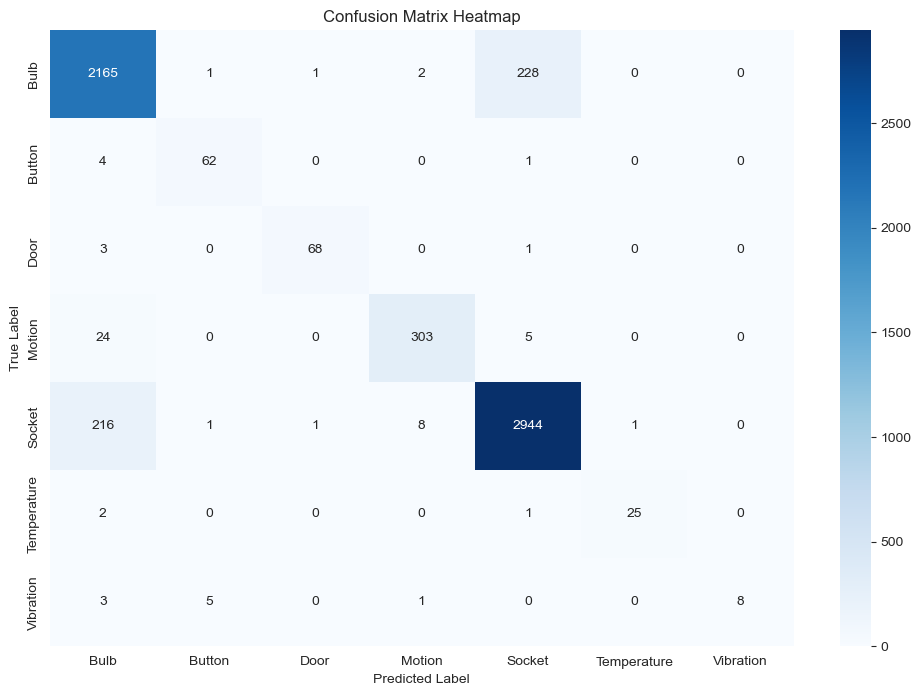

In [3]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

file_path =  "./Merged_Data/B_6-Merged_sequence_data_fix_packets/Topology_B_fix_packets.csv"
data = pd.read_csv(file_path)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Type"]

y = y.astype('category')
categories = y.cat.categories  
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))  

target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)
f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

### Identification

Category distribution:
13    4501
15    4224
14    4083
5     3931
9     2791
11    2070
8     1956
7     1823
10    1442
12    1389
6      998
0      358
2      233
20     193
18     158
3       83
4       70
16      34
17      34
1       31
19      14
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.90      0.97      0.94        67
        Aqara Door 1       1.00      1.00      1.00         4
        Aqara Door 2       0.90      0.96      0.93        49
        Aqara Motion       0.95      0.95      0.95        19
     Aqara Vibration       0.89      0.47      0.62        17
       Ledvance Bulb       0.73      0.78      0.76       761
Ledvance Smart+ Plug       0.68      0.70      0.69       178
    Ledvance Z3 Plug       0.78      0.67      0.72       377
           Moes Bulb       0.85      0.89      0.87       387
      Philips Lamp 1       0.68      0.66      0.67       559
      Philips Lamp 2       0.70      

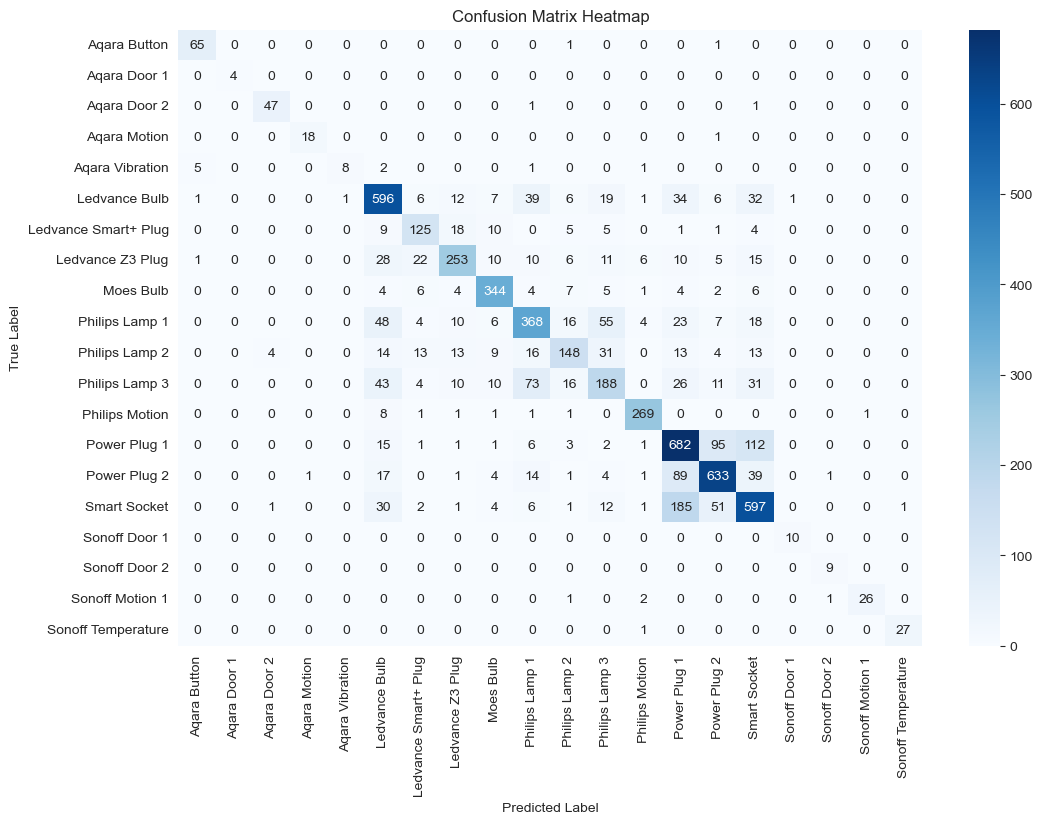

In [4]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

file_path =  "./Merged_Data/B_6-Merged_sequence_data_fix_packets/Topology_B_fix_packets.csv"
data = pd.read_csv(file_path)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Name"]

y = y.astype('category')
categories = y.cat.categories  
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))  

target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

## Train A Test B

### Classification

Category distribution:
0    11160
4     9693
3      830
2      604
1      227
6       71
5       63
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.67      0.77      0.72     12190
      Button       0.28      0.13      0.17       358
        Door       0.72      0.63      0.68       332
      Motion       0.74      0.55      0.63      1644
      Socket       0.80      0.76      0.78     15629
 Temperature       0.72      0.25      0.38       193
   Vibration       0.00      0.00      0.00        70

    accuracy                           0.74     30416
   macro avg       0.56      0.44      0.48     30416
weighted avg       0.74      0.74      0.74     30416

Macro F1-Score: 0.4790


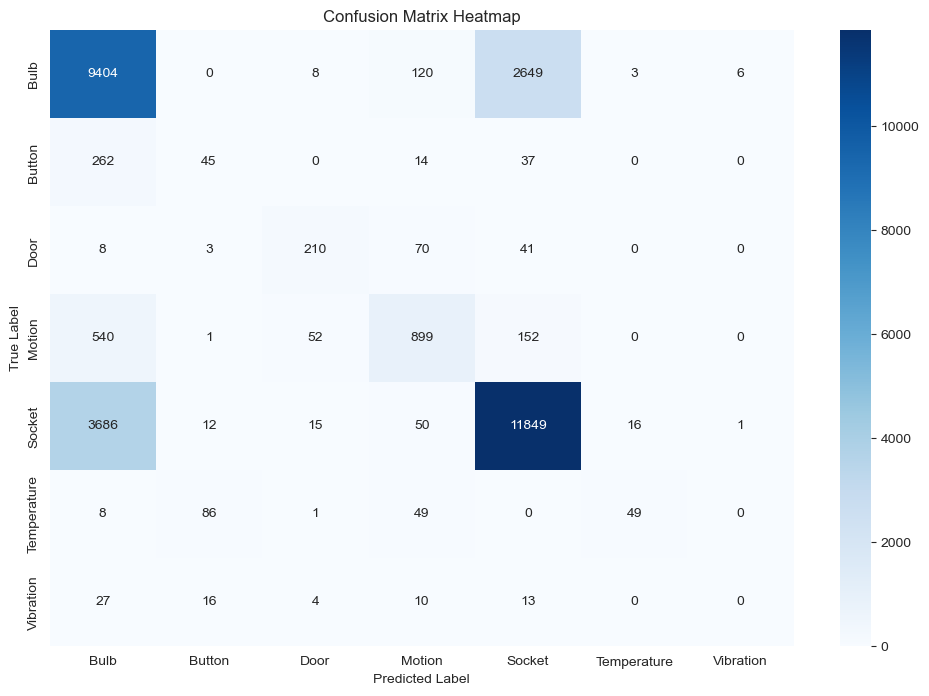

In [5]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Merged_Data/B_6-Merged_sequence_data_fix_packets/Topology_A_fix_packets.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type","File Name"])
y_train = train_data["Device Type"]

y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path =  "./Merged_Data/B_6-Merged_sequence_data_fix_packets/Topology_B_fix_packets.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type","File Name"])
y_test = test_data["Device Type"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()


### Identification

Category distribution:
5     3510
15    2700
12    2522
14    2500
13    2453
8     2201
9     1682
10    1245
6     1084
7      956
11     706
1      388
0      227
2      142
4       71
20      63
3       52
18      44
17      38
16      36
19      28
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.35      0.21      0.26       358
        Aqara Door 1       0.00      0.00      0.00        31
        Aqara Door 2       0.07      0.01      0.02       233
        Aqara Motion       0.26      0.12      0.17        83
     Aqara Vibration       0.03      0.01      0.02        70
       Ledvance Bulb       0.47      0.53      0.50      3931
Ledvance Smart+ Plug       0.17      0.12      0.14       998
    Ledvance Z3 Plug       0.32      0.32      0.32      1823
           Moes Bulb       0.40      0.43      0.41      1956
      Philips Lamp 1       0.26      0.17      0.21      2791
      Philips Lamp 2       0.14      

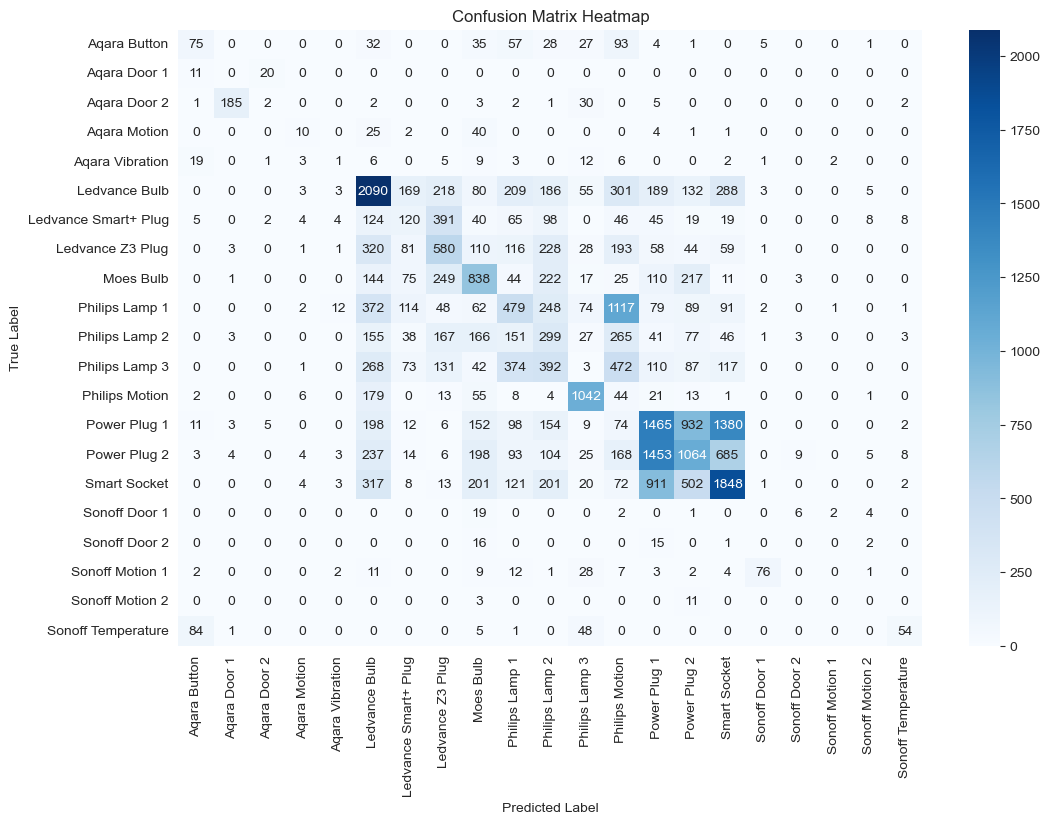

In [6]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Merged_Data/B_6-Merged_sequence_data_fix_packets/Topology_A_fix_packets.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type","File Name"])
y_train = train_data["Device Name"]

y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path =  "./Merged_Data/B_6-Merged_sequence_data_fix_packets/Topology_B_fix_packets.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type","File Name"])
y_test = test_data["Device Name"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()


## Train B Test A

### Classification

Category distribution:
4    15629
0    12190
3     1644
1      358
2      332
5      193
6       70
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.80      0.82      0.81     11160
      Button       0.29      0.03      0.05       227
        Door       0.79      0.48      0.60       604
      Motion       0.65      0.40      0.50       830
      Socket       0.78      0.82      0.80      9693
 Temperature       0.26      0.78      0.39        63
   Vibration       0.00      0.00      0.00        71

    accuracy                           0.78     22648
   macro avg       0.51      0.47      0.45     22648
weighted avg       0.78      0.78      0.78     22648

Macro F1-Score: 0.4484


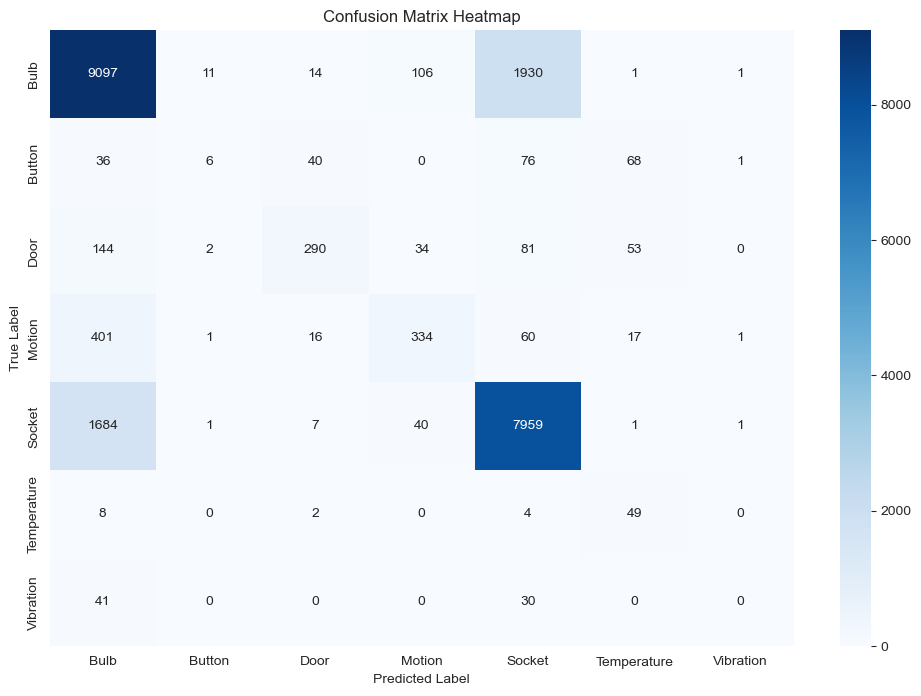

In [7]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Merged_Data/B_6-Merged_sequence_data_fix_packets/Topology_B_fix_packets.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type","File Name"])
y_train = train_data["Device Type"]
y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path = "./Merged_Data/B_6-Merged_sequence_data_fix_packets/Topology_A_fix_packets.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type","File Name"])
y_test = test_data["Device Type"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes


class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()


### Identification

Category distribution:
13    4501
15    4224
14    4083
5     3931
9     2791
11    2070
8     1956
7     1823
10    1442
12    1389
6      998
0      358
2      233
20     193
18     158
3       83
4       70
16      34
17      34
1       31
19      14
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.00      0.00      0.00       227
        Aqara Door 1       0.00      0.00      0.00       388
        Aqara Door 2       0.13      0.50      0.21       142
        Aqara Motion       0.93      0.27      0.42        52
     Aqara Vibration       0.00      0.00      0.00        71
       Ledvance Bulb       0.51      0.60      0.55      3510
Ledvance Smart+ Plug       0.36      0.15      0.21      1084
    Ledvance Z3 Plug       0.35      0.38      0.36       956
           Moes Bulb       0.68      0.34      0.45      2201
      Philips Lamp 1       0.19      0.37      0.25      1682
      Philips Lamp 2       0.15      

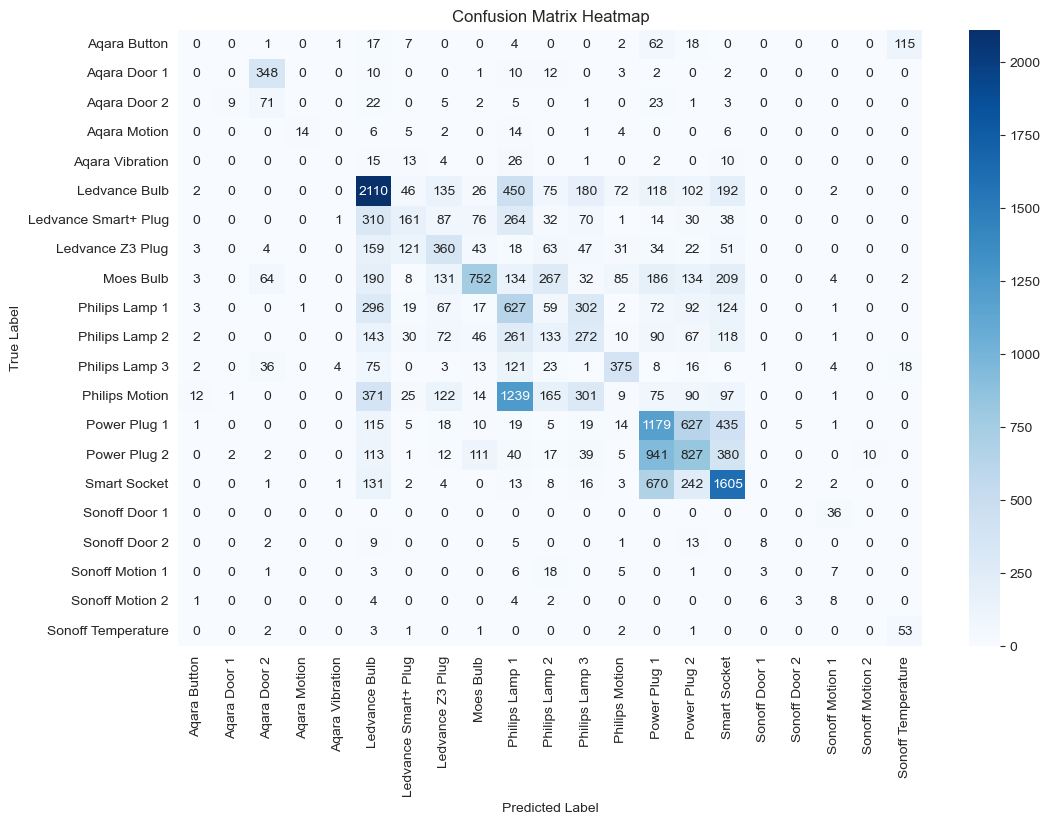

In [8]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Merged_Data/B_6-Merged_sequence_data_fix_packets/Topology_B_fix_packets.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type","File Name"])
y_train = train_data["Device Name"]

y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path =  "./Merged_Data/B_6-Merged_sequence_data_fix_packets/Topology_A_fix_packets.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type","File Name"])
y_test = test_data["Device Name"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()
